In [ ]:
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')  # or encoding='ISO-8859-1'
print(df.head())
print(df.columns)

import os

# Show current working directory
print("Working directory:", os.getcwd())

# List files in the current directory
print("Files in current directory:", os.listdir("."))

# Also check the output/ folder if you use it
print("Files in output/:", os.listdir("output") if os.path.exists("output") else "output/ does not exist")

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [ ]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


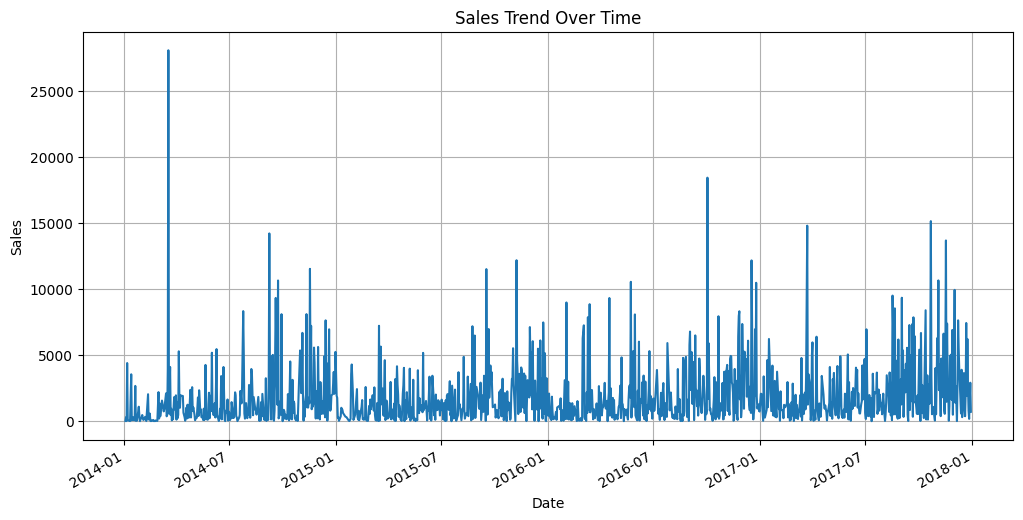

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Order Date to date format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Group sales by date
daily_sales = df.groupby('Order Date')['Sales'].sum()

# Plot sales trend
plt.figure(figsize=(12,6))
daily_sales.plot()
plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

In [ ]:
!pip install prophet

In [ ]:
sales_data = df.groupby('Order Date')['Sales'].sum().reset_index()

sales_data.columns = ['ds', 'y']

sales_data.head()

,ds,y
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [ ]:
from prophet import Prophet

model = Prophet()

model.fit(sales_data)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast[['ds','yhat']].tail()

,ds,yhat
1262,2018-01-25,1968.779331
1263,2018-01-26,2265.827233
1264,2018-01-27,1894.228723
1265,2018-01-28,2095.574381
1266,2018-01-29,2314.168560


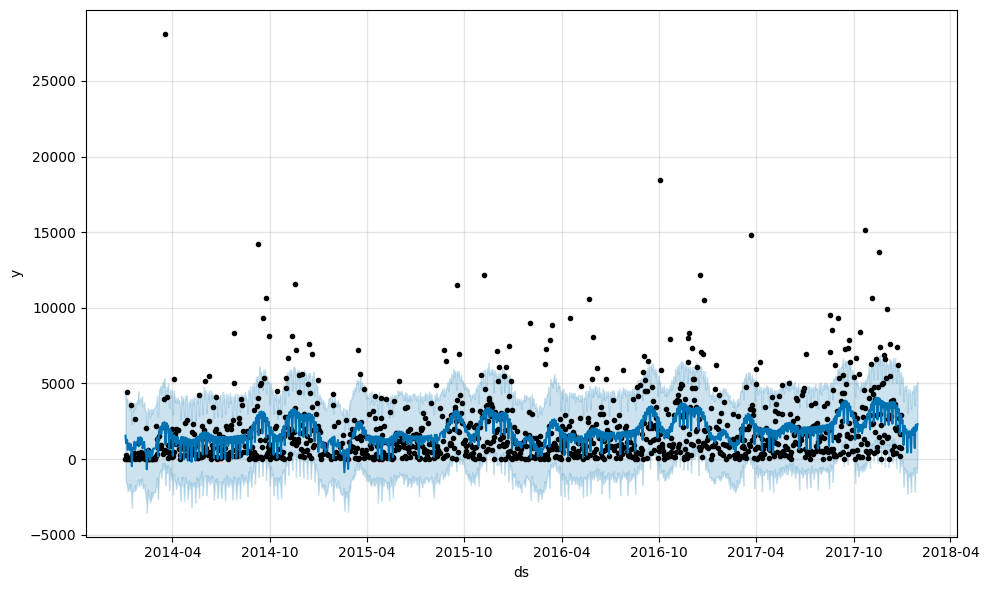

In [ ]:
fig = model.plot(forecast)